# Experiment 2: Outlier Extremity and Sample Size

This notebook reproduces the findings from two key sections of the paper "**Systematic differences as a function of outlier extremity**" and subsequently "**Increasing the sample size does not erase the differences**". While Experiment 1 provided a static snapshot of contamination, this notebook explores the dynamic behavior of our five Bayesian models under two varying conditions.

1. **Outlier Extremity (Figure 4):** We hold the sample size constant ($N = 6$) but incrementally push the value of the single contaminant from 0 to 25. This visualizes the influence curve of each model, demonstrating whether a model's estimate is bounded (robust) or if it grows infinitely alongside the outlier (non-robust).

2. **Sample Size Scaling (Figure 5):** We hold the outlier value constant ($x = 15$) and the contamination proportion constant ($~16.7%$), but increase the total sample size from $N = 6$ to $N = 90$. This demonstrates that simply gathering more data does not cure a non-robust model; it only makes the model mathematically certain of the wrong answer.

In [16]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import MCMC, NUTS, Predictive
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import helper function from the src directory
from src.inference.runner import run_parametric_mcmc

# Import models from the src directory
from src.models import (
    normal_model,
    contaminated_normal_model,
    student_t_model,
    bayesian_bootstrap_mean,
    bayesian_bootstrap_trimmed
)

# Import data from the data directory
data = jnp.load('../data/toy_dataset.npy')
print(f"Imported toy data: {data}")

Imported toy data: [-2. -1.  0.  1.  2. 15.]


# Figure 4
## Implementation
We smoothly vary the location of the sixth data point from $x=0$ to $x=25$, and observe how the credible intervals change for all five Bayesian methods. The model definitions can be found in `/src/models/` and the helper function in `/src/inference/runner.py`. 

Note that the `num_samples=4000` and `num_warmup=1000` are arbitrarily chosen and was not explicitly mentioned by the author.

In [17]:
# 1. Define the range
base_data = data[:-1]
outlier_values = np.linspace(0, 25, 26)

# 2. Storage
results = []

# 3. Run the loop
for val in outlier_values:
    # Update the data
    current_data = jnp.append(base_data, val)

    # Run Parametric Models (MCMC)
    mu_normal = run_parametric_mcmc(normal_model, current_data)["mu"]
    mu_contaminated = run_parametric_mcmc(contaminated_normal_model, current_data)["mu"]
    mu_student = run_parametric_mcmc(student_t_model, current_data)["mu"]

    # Run Nonparametric Models (Predictive)
    predictive_bb_mean = Predictive(bayesian_bootstrap_mean, num_samples=4000)
    mu_bb_mean = predictive_bb_mean(jax.random.PRNGKey(int(val)), current_data)["mu"]

    predictive_bb_trim = Predictive(bayesian_bootstrap_trimmed, num_samples=4000)
    mu_bb_trim = predictive_bb_trim(jax.random.PRNGKey(int(val)+1), current_data)["mu"]

    # Store Results
    for model_name, samples in zip(
        ["Normal model", "Contaminated normal model", "t-distribution", "BB mean", "BB trimmed mean"],
        [mu_normal, mu_contaminated, mu_student, mu_bb_mean, mu_bb_trim]
    ):
        results.append({
            "outlier": val,
            "model": model_name,
            "mean": np.mean(samples),
            "ci_lower": np.percentile(samples, 2.5),
            "ci_upper": np.percentile(samples, 97.5)
        })

df = pd.DataFrame(results)


sample: 100%|██████████| 5000/5000 [00:01<00:00, 4530.66it/s, 5 steps of size 5.60e-01. acc. prob=0.87]


We now plot the posterior credible intervals change as a function of the extremity of an outlier.

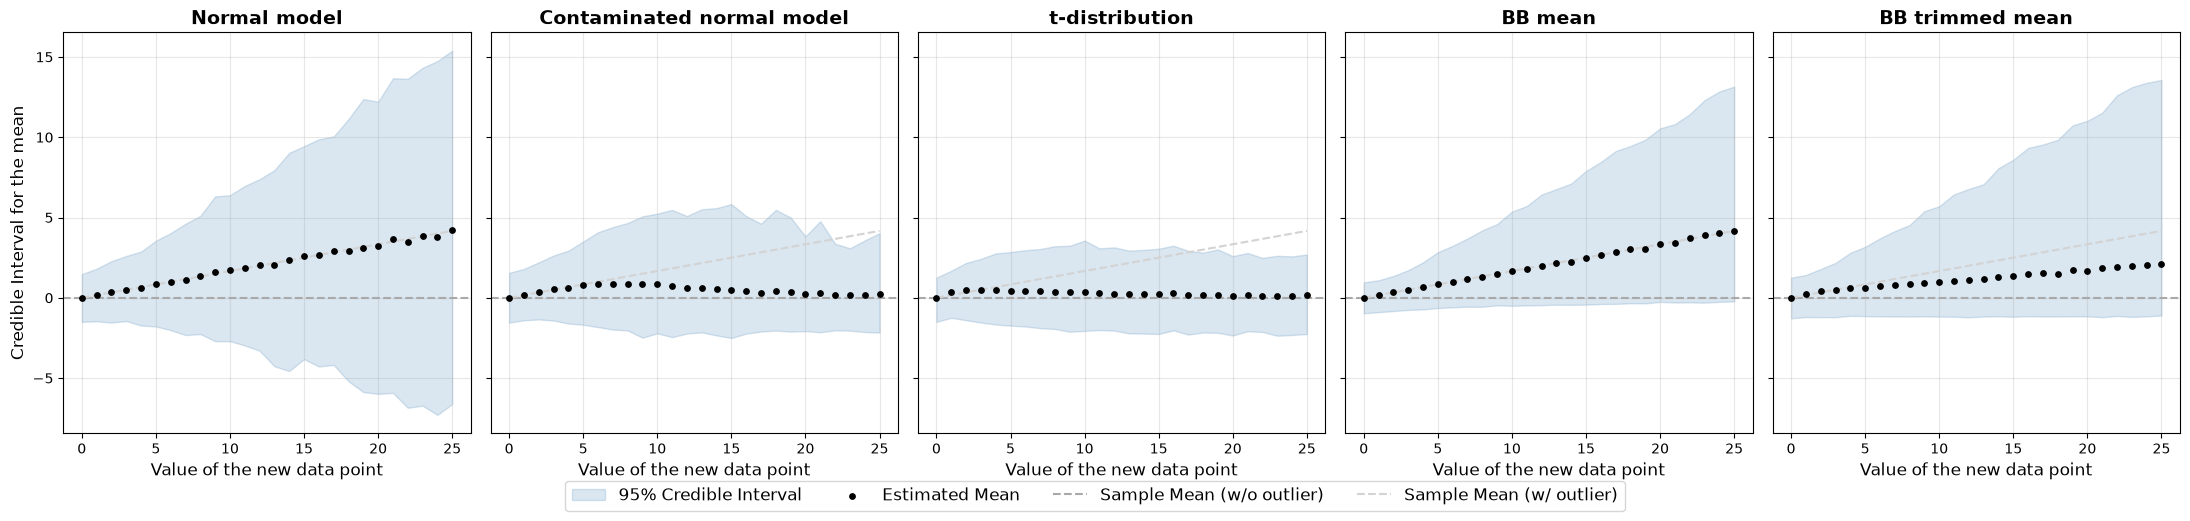

In [18]:
# Calculate the mean of the sample without the outlier
mean_no_outlier = jnp.mean(base_data)

# Calculate the mean of the sample including the outlier
mean_with_outlier = (jnp.sum(base_data) + outlier_values) / (len(base_data) + 1)

# Get unique models
models = df["model"].unique()

# Create a 1x5 grid of plots sharing the same y-axis
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, model_name in zip(axes, models):
    # Filter dataframe for the current model
    model_df = df[df["model"] == model_name]
    
    # 1. Shaded area depicting the credible interval
    ax.fill_between(
        model_df["outlier"], 
        model_df["ci_lower"], 
        model_df["ci_upper"], 
        color='steelblue', 
        alpha=0.2,
        label="95% Credible Interval"
    )
    
    # 2. Dark points showing the population mean estimated by the model
    ax.scatter(
        model_df["outlier"], 
        model_df["mean"], 
        color='black', 
        s=15, 
        zorder=3, 
        label="Estimated Mean"
    )
    
    # 3. Light grey dashed line: mean without the extreme point
    ax.axhline(
        mean_no_outlier, 
        color='darkgrey', 
        linestyle='--', 
        label="Sample Mean (w/o outlier)"
    )
    
    # 4. Light grey dashed line: mean WITH the extreme point
    ax.plot(
        outlier_values, 
        mean_with_outlier, 
        color='lightgrey', 
        linestyle='--', 
        label="Sample Mean (w/ outlier)"
    )
    
    # Formatting
    ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Value of the new data point", fontsize=12)
    ax.grid(alpha=0.3)

# Axes labels and legend
axes[0].set_ylabel("Credible Interval for the mean", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()


## Discussion

We note that the reproduced result closely resembles the plot provided in the paper. Notably:

### Best Point Estimate
- The Normal model and the BB-mean model, the best estimate of the population mean(the black dot) closely traces the sample mean(diagonal grey dotted line). In other words, the more extreme the outlier becomes, the more extreme the estimated population mean becomes. 
- The t-distribution model, contaminated normal model, and BB-trimmed models all discount the outlier but seemingly in different ways. 
    - BB-trimmed model discounts the most extreme observations, as the estimated population mean rises more slowly than the sample mean, but it rises monotonically. 
    - Contaminated normal model behaves similarly to the normal model for very most outliers (up to about $x=6$, in accordance with the paper) but beyond a threshold, the model starts to discount the outlier to reduce the estimated population mean. By $x=25$, the influence of the outlier has almost been completely discounted where the best estimate is close to zero, which is the sample mean without the outlier. 
    - t-distribution model behaves similarly to the contaminated normal model but much earlier, it starts to discount this extreme point. 

### Credible Interval
- Normal model and t-distribution model are symmetric
- The BB models displays no such symmetry. A shift in the outlier produces a change in the upper end of the credible interval that matches the change produced by the normal model, but the lower bound is largely unaffected. 
- Contaminated model, for modest outliers look identical to the normal model with symmetry, but once the model begins to discount the outlier, the lower bound stays mostly constant and the upper bound continues the rise until eventually fall back down.
- t-distribution model displays relatively consistent credible interval regardless of the value of the outlier.

# Figure 5
## Implementation

We now consider how the models make different inferences as a function of sample size.

In [19]:
# 1. Define the range
sample_multipliers = np.arange(1, 16)
base_data = data

# 2. Storage
results_fig5 = []

# 3. Run the loop

for k in sample_multipliers:
    # Tile the data to strictly preserve the 16.6% contamination
    data = jnp.tile(base_data, k)
    N = len(data)
    
    # --- 1. Parametric Models (MCMC) ---
    # Double-check that 'data' (not base_data) is passed here!
    mu_normal = run_parametric_mcmc(normal_model, data, num_samples=4000)["mu"]
    mu_student = run_parametric_mcmc(student_t_model, data, num_samples=4000)["mu"]
    mu_contam = run_parametric_mcmc(contaminated_normal_model, data, num_samples=4000)["mu"]
    
    # --- 2. Nonparametric Models (Predictive) ---
    pred_bb_mean = Predictive(bayesian_bootstrap_mean, num_samples=4000)
    mu_bb_mean = pred_bb_mean(jax.random.PRNGKey(k), data)["mu"]
    
    pred_bb_trim = Predictive(bayesian_bootstrap_trimmed, num_samples=4000)
    mu_bb_trim = pred_bb_trim(jax.random.PRNGKey(k + 100), data)["mu"]
    
    # --- 3. Store Results ---
    for model_name, samples in zip(
        ["Normal model", "Contaminated normal model", "t-distribution", "BB mean", "BB trimmed mean"],
        [mu_normal, mu_contam, mu_student, mu_bb_mean, mu_bb_trim]
    ):
        results_fig5.append({
            "N": N,
            "model": model_name,
            "mean": np.mean(samples),
            "ci_lower": np.percentile(samples, 2.5),
            "ci_upper": np.percentile(samples, 97.5)
        })

df_fig5 = pd.DataFrame(results_fig5)


sample: 100%|██████████| 5000/5000 [00:01<00:00, 2991.98it/s, 15 steps of size 2.77e-01. acc. prob=0.95]


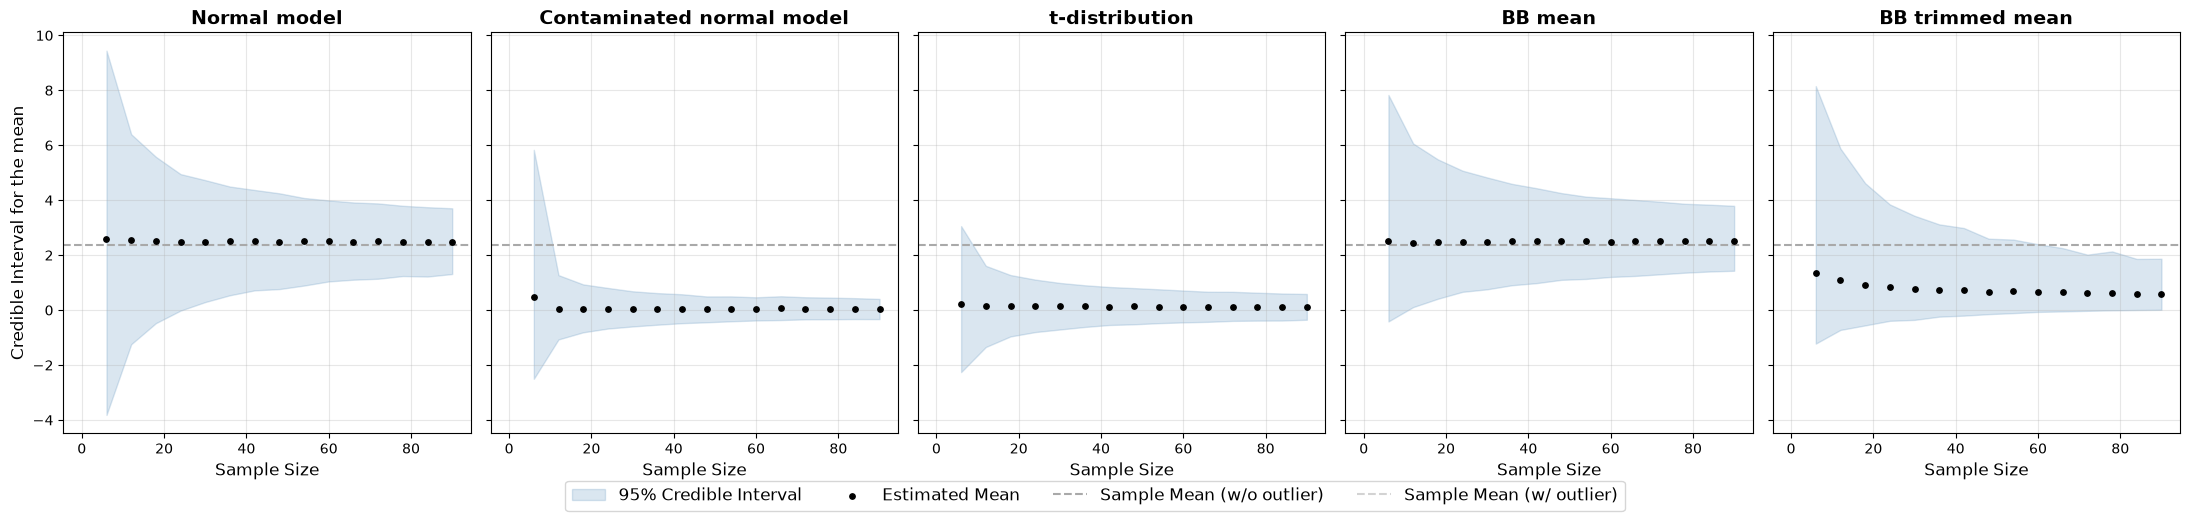

In [20]:
# Calculate the mean of the sample without the outlier
mean_no_outlier = jnp.mean(data[:-1])

# Calculate the mean of the sample including the outlier
mean_with_outlier = jnp.sum(data) / len(data)

# Get unique models
models = df_fig5["model"].unique()

# Create a 1x5 grid of plots sharing the same y-axis
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, model_name in zip(axes, models):
    # Filter dataframe for the current model
    model_df = df_fig5[df_fig5["model"] == model_name]
    
    # 1. Shaded area depicting the credible interval
    ax.fill_between(
        model_df["N"], 
        model_df["ci_lower"], 
        model_df["ci_upper"], 
        color='steelblue', 
        alpha=0.2,
        label="95% Credible Interval"
    )
    
    # 2. Dark points showing the population mean estimated by the model
    ax.scatter(
        model_df["N"], 
        model_df["mean"], 
        color='black', 
        s=15, 
        zorder=3, 
        label="Estimated Mean"
    )
    
    # 3. Light grey dashed line: mean without the extreme point
    ax.axhline(
        mean_no_outlier, 
        color='darkgrey', 
        linestyle='--', 
        label="Sample Mean (w/o outlier)"
    )
    
    # 4. Light grey dashed line: mean WITH the extreme point
    ax.plot(
        mean_with_outlier, 
        color='lightgrey', 
        linestyle='--', 
        label="Sample Mean (w/ outlier)"
    )
    
    # Formatting
    ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample Size", fontsize=12)
    ax.grid(alpha=0.3)

# Axes labels and legend
axes[0].set_ylabel("Credible Interval for the mean", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()


## Discussion

### Best Point Estimate
- Normal model and the BB-mean model produce estimates of the population mean that track the sample mean, despite the increase in sample size. 
- BB-trimmed model also produces estimates of the population mean that track the 20% trimmed sample mean at around 0.5. 
- Contaminated normal model and t-distribution model converge their estimate of the population mean to 0, as they become increasingly certain that the outliers are contaminants. 